### ESAM 495 Assignment 1: Mass-Action Kinetics and Detailed Balance

Author: Phoebe Kuang

Date: Apr 18, 2026

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import scipy.constants as const
from scipy.integrate import solve_ivp
from scipy.integrate import quad
from scipy.optimize import minimize_scalar
import seaborn as sns

sns.set_theme(font_scale=1.5)
sns.set_style("whitegrid")

#### 1 Irreversible System

##### 1.3 Simulation for Specific Rates

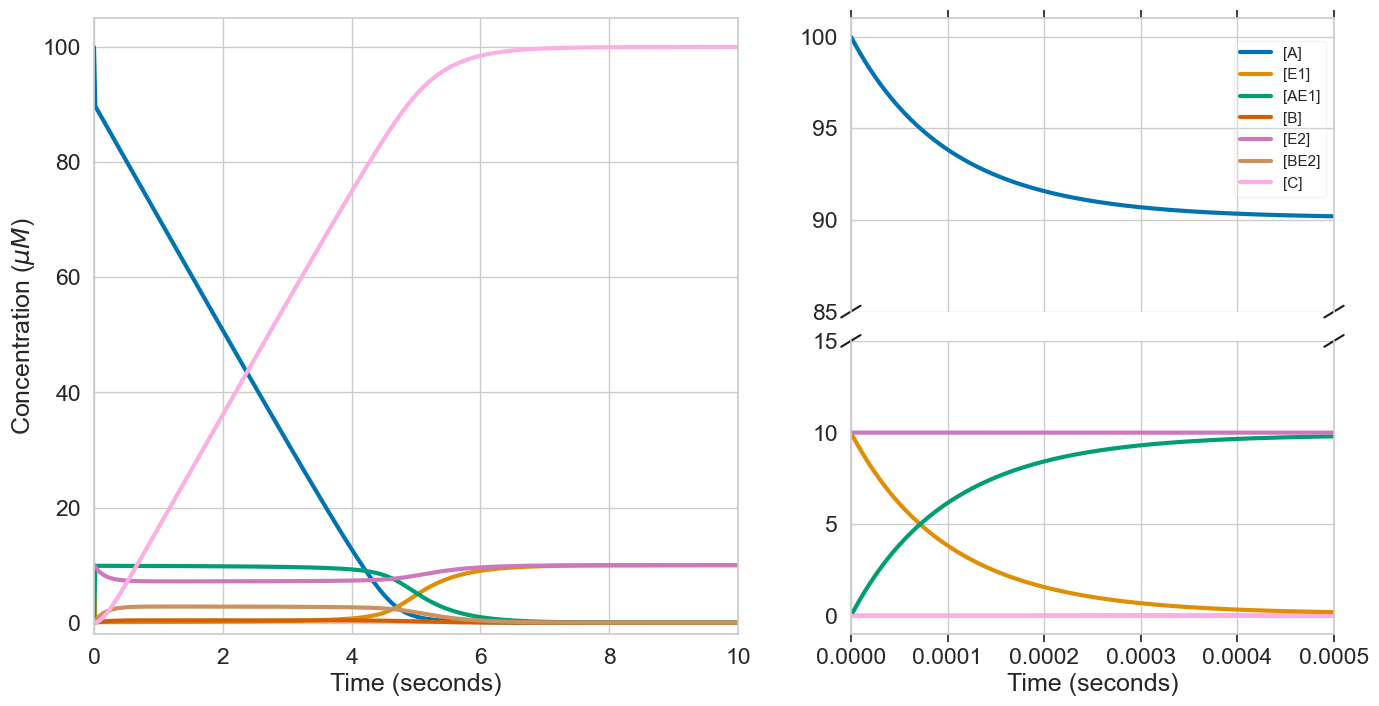

In [2]:
# Parameters
kb = 100.0  # uM^-1 s^-1
ku = 100.0  # s^-1
k1 = 2.0    # s^-1
k2 = 7.0    # s^-1
# k_-1 and k_-2 are 0 for the irreversible system

# Initial Conditions: [A, E1, AE1, B, E2, BE2, C]
y0 = [100.0, 10.0, 0.0, 0.0, 10.0, 0.0, 0.0]

# ODE system (1.1)
def irreversible_kinetics(t, y):
    A, E1, AE1, B, E2, BE2, C = y
    
    dA_dt = -kb * A * E1 + ku * AE1
    dE1_dt = -kb * A * E1 + (ku + k1) * AE1
    dAE1_dt = kb * A * E1 - (ku + k1) * AE1
    
    dB_dt = k1 * AE1 - kb * B * E2 + ku * BE2
    dE2_dt = -kb * B * E2 + (ku + k2) * BE2
    dBE2_dt = kb * B * E2 - (ku + k2) * BE2
    
    dC_dt = k2 * BE2
    
    return [dA_dt, dE1_dt, dAE1_dt, dB_dt, dE2_dt, dBE2_dt, dC_dt]

# Solve the ODE using a stiff solver (Radau/BDF)
# Solve up to 10 seconds to guarantee steady state
sol = solve_ivp(irreversible_kinetics, [0, 10], y0, method='Radau', dense_output=True)
# Notes: Use dense_output=True to get a continuous solution (for plotting at different time scales).

# Create two time arrays for our two different scales
t_outer = np.linspace(0, 10, 500)      # Outer Layer (Seconds)
t_inner = np.linspace(0, 5e-4, 500)    # Inner Layer (Milliseconds)

# Evaluate the solution
y_outer = sol.sol(t_outer)
y_inner = sol.sol(t_inner)

# Visualization
fig = plt.figure(figsize=(16, 8))
labels = ['[A]', '[E1]', '[AE1]', '[B]', '[E2]', '[BE2]', '[C]']
colors = sns.color_palette("colorblind", n_colors=7)
linewidth = 3

gs = gridspec.GridSpec(2, 2, height_ratios=[1, 1], width_ratios=[1, 0.75])
gs.update(hspace=0.1)

ax_outer = fig.add_subplot(gs[:, 0])            # Left Plot (Outer System)
ax_inner_top = fig.add_subplot(gs[0, 1])        # Right Top Plot (Inner System, Substrate)
ax_inner_bot = fig.add_subplot(gs[1, 1], sharex=ax_inner_top) # Right Bottom Plot (Inner System, Complex)

# Left Plot: Outer System
for i in range(7):
    ax_outer.plot(t_outer, y_outer[i], label=labels[i], color=colors[i], lw=linewidth)

ax_outer.set_xlabel('Time (seconds)')
ax_outer.set_ylabel('Concentration ($\mu M$)')
ax_outer.set_xlim(0, 10)
ax_outer.set_ylim(-2, 105)


# Right Plot: Inner System (Zoomed in on the first 0.5 ms)
for i in range(7):
    ax_inner_top.plot(t_inner, y_inner[i], label=labels[i], color=colors[i], lw=linewidth)
    ax_inner_bot.plot(t_inner, y_inner[i], label=labels[i], color=colors[i], lw=linewidth)

ax_inner_top.set_ylim(85, 101)
ax_inner_bot.set_ylim(-1, 15)
ax_inner_bot.set_xlim(0, 5e-4)
ax_inner_bot.set_xlabel('Time (seconds)')
ax_inner_top.spines['bottom'].set_visible(False)
ax_inner_bot.spines['top'].set_visible(False)
ax_inner_top.xaxis.tick_top()
ax_inner_top.tick_params(labeltop=False)  # Remove X-ticks from the top plot
ax_inner_bot.xaxis.tick_bottom()

# Add the diagonal cut marks (//) to indicate the Y-axis break
d = .02
kwargs = dict(transform=ax_inner_top.transAxes, color='k', clip_on=False, lw=1.5)
ax_inner_top.plot((-d, +d), (-d, +d), **kwargs) 
ax_inner_top.plot((1 - d, 1 + d), (-d, +d), **kwargs) 
kwargs.update(transform=ax_inner_bot.transAxes)  
ax_inner_bot.plot((-d, +d), (1 - d, 1 + d), **kwargs) 
ax_inner_bot.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)

ax_inner_top.legend(loc='upper right', fontsize=11, framealpha=0.2, bbox_to_anchor=(1.0, 0.95))

plt.show()

##### 1.4 Simulation for system with constantly replenished A

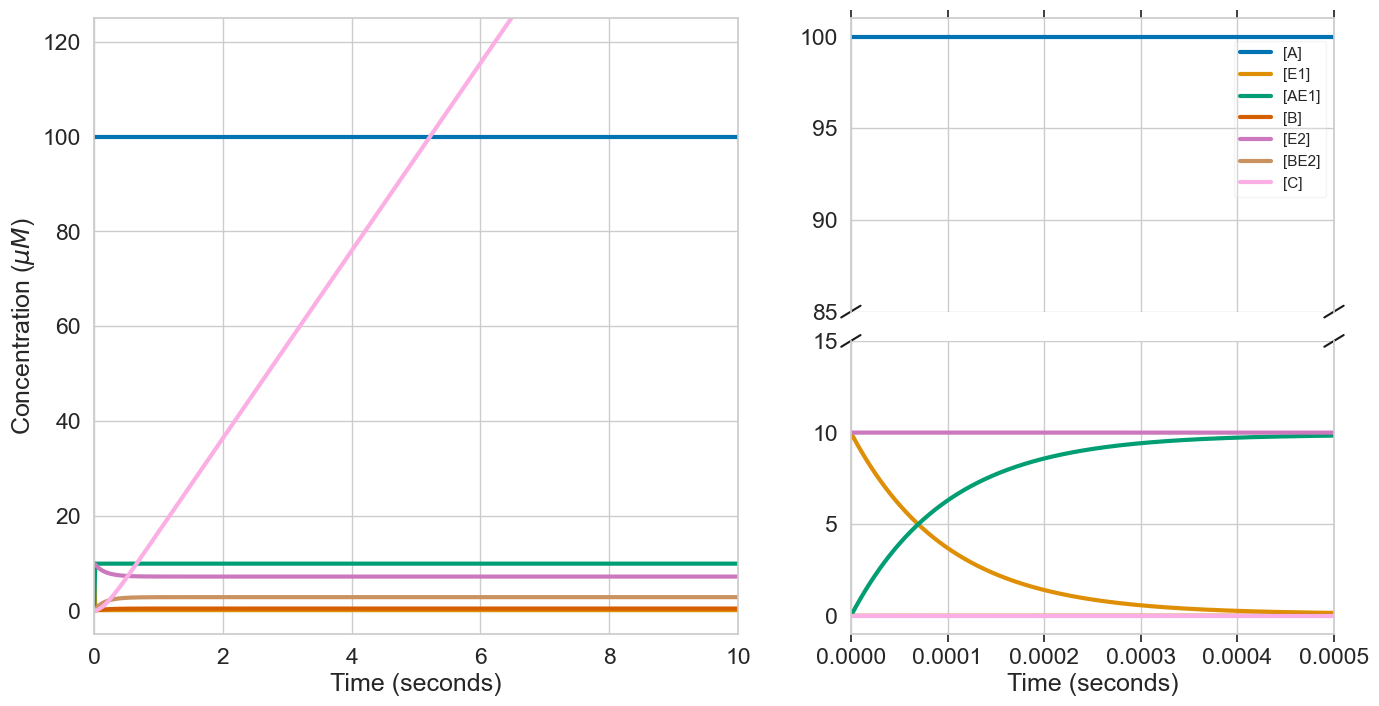

In [3]:
# Parameters (Same as 1.3)
kb = 100.0  
ku = 100.0  
k1 = 2.0    
k2 = 7.0    

# Initial Conditions: [A, E1, AE1, B, E2, BE2, C]
y0 = [100.0, 10.0, 0.0, 0.0, 10.0, 0.0, 0.0]

# ODE system (1.4 - Replenished A)
def replenished_kinetics(t, y):
    A, E1, AE1, B, E2, BE2, C = y
    
    # [A] is held constant, so its derivative is 0
    dA_dt = 0.0 
    
    dE1_dt = -kb * A * E1 + (ku + k1) * AE1
    dAE1_dt = kb * A * E1 - (ku + k1) * AE1
    
    dB_dt = k1 * AE1 - kb * B * E2 + ku * BE2
    dE2_dt = -kb * B * E2 + (ku + k2) * BE2
    dBE2_dt = kb * B * E2 - (ku + k2) * BE2
    
    dC_dt = k2 * BE2
    
    return [dA_dt, dE1_dt, dAE1_dt, dB_dt, dE2_dt, dBE2_dt, dC_dt]

# Solve the ODE
sol_rep = solve_ivp(replenished_kinetics, [0, 10], y0, method='Radau', dense_output=True)

# Create two time arrays for our two different scales
t_outer = np.linspace(0, 10, 500)      # Outer Layer (Seconds)
t_inner = np.linspace(0, 5e-4, 500)    # Inner Layer (Milliseconds)

# Evaluate the solution
y_outer = sol_rep.sol(t_outer)
y_inner = sol_rep.sol(t_inner)

# Visualization
fig = plt.figure(figsize=(16, 8))
labels = ['[A]', '[E1]', '[AE1]', '[B]', '[E2]', '[BE2]', '[C]']
colors = sns.color_palette("colorblind", n_colors=7)
linewidth = 3

gs = gridspec.GridSpec(2, 2, height_ratios=[1, 1], width_ratios=[1, 0.75])
gs.update(hspace=0.1)

ax_outer = fig.add_subplot(gs[:, 0])            # Left Plot (Outer System)
ax_inner_top = fig.add_subplot(gs[0, 1])        # Right Top Plot (Inner System, Substrate)
ax_inner_bot = fig.add_subplot(gs[1, 1], sharex=ax_inner_top) # Right Bottom Plot (Inner System, Complex)

# Left Plot: Outer System
for i in range(7):
    ax_outer.plot(t_outer, y_outer[i], label=labels[i], color=colors[i], lw=linewidth)

ax_outer.set_xlabel('Time (seconds)')
ax_outer.set_ylabel('Concentration ($\mu M$)')
ax_outer.set_xlim(0, 10)
ax_outer.set_ylim(-5, 125) 

# Right Plot: Inner System (Zoomed in on the first 0.5 ms)
for i in range(7):
    ax_inner_top.plot(t_inner, y_inner[i], label=labels[i], color=colors[i], lw=linewidth)
    ax_inner_bot.plot(t_inner, y_inner[i], label=labels[i], color=colors[i], lw=linewidth)

ax_inner_top.set_ylim(85, 101)
ax_inner_bot.set_ylim(-1, 15)
ax_inner_bot.set_xlim(0, 5e-4)
ax_inner_bot.set_xlabel('Time (seconds)')

ax_inner_top.spines['bottom'].set_visible(False)
ax_inner_bot.spines['top'].set_visible(False)
ax_inner_top.xaxis.tick_top()
ax_inner_top.tick_params(labeltop=False)  
ax_inner_bot.xaxis.tick_bottom()

# Add the diagonal cut marks (//) to indicate the Y-axis break
d = .02
kwargs = dict(transform=ax_inner_top.transAxes, color='k', clip_on=False, lw=1.5)
ax_inner_top.plot((-d, +d), (-d, +d), **kwargs) 
ax_inner_top.plot((1 - d, 1 + d), (-d, +d), **kwargs) 
kwargs.update(transform=ax_inner_bot.transAxes)  
ax_inner_bot.plot((-d, +d), (1 - d, 1 + d), **kwargs) 
ax_inner_bot.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)

ax_inner_top.legend(loc='upper right', fontsize=11, framealpha=0.2, bbox_to_anchor=(1.0, 0.95))

plt.show()

#### 2 Reversible System

##### 2.3 Simulation for Specific Rates

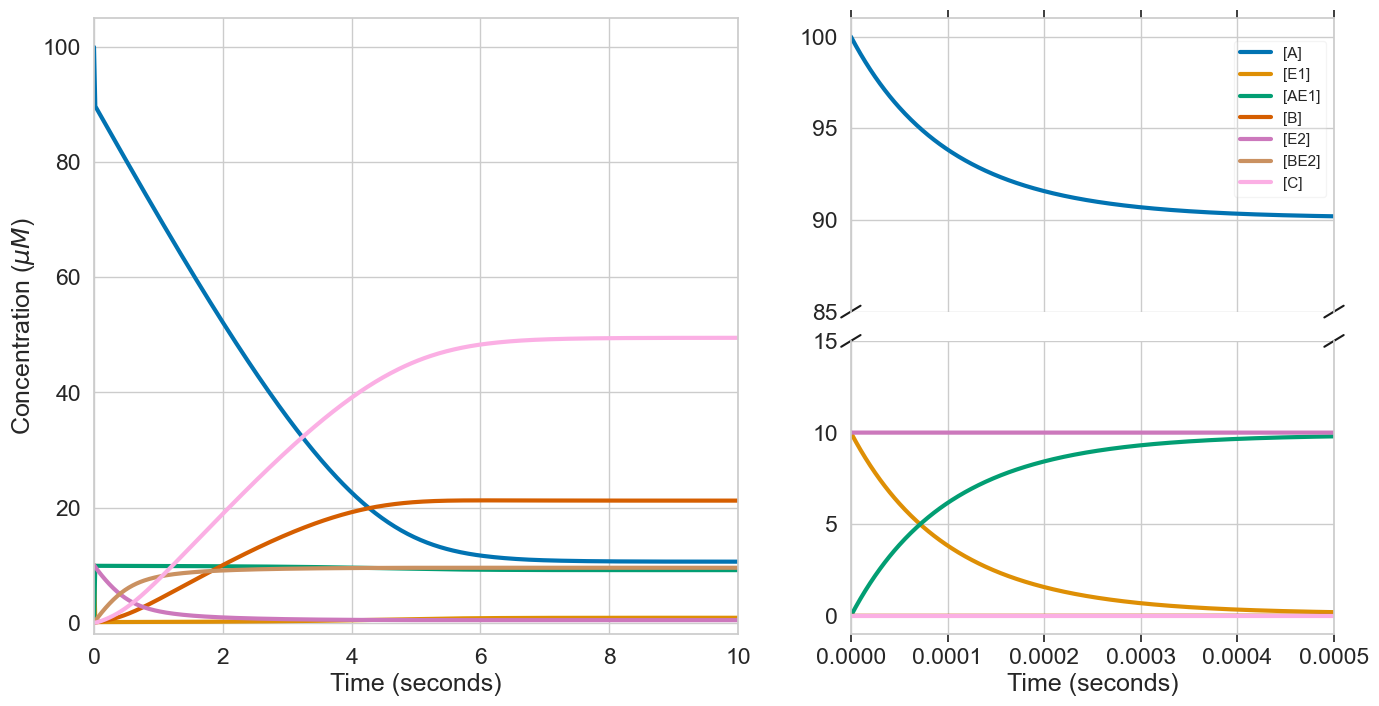

Numerical Steady States at t=10s:
[A] = 10.61
[E1] = 0.86
[AE1] = 9.14
[B] = 21.21
[E2] = 0.45
[BE2] = 9.55
[C] = 49.49


In [4]:
# New Parameters (Reversible)
k_minus1 = 1.0  
k_minus2 = 3.0  

y0 = [100.0, 10.0, 0.0, 0.0, 10.0, 0.0, 0.0]

def reversible_kinetics(t, y):
    A, E1, AE1, B, E2, BE2, C = y
    
    dA_dt = -kb * A * E1 + ku * AE1
    dE1_dt = -kb * A * E1 + (ku + k1) * AE1 - k_minus1 * B * E1
    dAE1_dt = kb * A * E1 - (ku + k1) * AE1 + k_minus1 * B * E1
    
    dB_dt = k1 * AE1 - k_minus1 * B * E1 - kb * B * E2 + ku * BE2
    dE2_dt = -kb * B * E2 + (ku + k2) * BE2 - k_minus2 * C * E2
    dBE2_dt = kb * B * E2 - (ku + k2) * BE2 + k_minus2 * C * E2
    
    dC_dt = k2 * BE2 - k_minus2 * C * E2
    
    return [dA_dt, dE1_dt, dAE1_dt, dB_dt, dE2_dt, dBE2_dt, dC_dt]

sol_rev = solve_ivp(reversible_kinetics, [0, 10], y0, method='Radau', dense_output=True)

t_outer = np.linspace(0, 10, 500)      
t_inner = np.linspace(0, 5e-4, 500)    

y_outer = sol_rev.sol(t_outer)
y_inner = sol_rev.sol(t_inner)

# Visualization
fig = plt.figure(figsize=(16, 8))
labels = ['[A]', '[E1]', '[AE1]', '[B]', '[E2]', '[BE2]', '[C]']
colors = sns.color_palette("colorblind", n_colors=7)
linewidth = 3

gs = gridspec.GridSpec(2, 2, height_ratios=[1, 1], width_ratios=[1, 0.75])
gs.update(hspace=0.1)

ax_outer = fig.add_subplot(gs[:, 0])            
ax_inner_top = fig.add_subplot(gs[0, 1])        
ax_inner_bot = fig.add_subplot(gs[1, 1], sharex=ax_inner_top) 

# Left Plot: Outer System
for i in range(7):
    ax_outer.plot(t_outer, y_outer[i], label=labels[i], color=colors[i], lw=linewidth)

ax_outer.set_xlabel('Time (seconds)')
ax_outer.set_ylabel('Concentration ($\mu M$)')
ax_outer.set_xlim(0, 10)
ax_outer.set_ylim(-2, 105)

# Right Plot: Inner System
for i in range(7):
    ax_inner_top.plot(t_inner, y_inner[i], label=labels[i], color=colors[i], lw=linewidth)
    ax_inner_bot.plot(t_inner, y_inner[i], label=labels[i], color=colors[i], lw=linewidth)

ax_inner_top.set_ylim(85, 101)
ax_inner_bot.set_ylim(-1, 15)
ax_inner_bot.set_xlim(0, 5e-4)
ax_inner_bot.set_xlabel('Time (seconds)')

ax_inner_top.spines['bottom'].set_visible(False)
ax_inner_bot.spines['top'].set_visible(False)
ax_inner_top.xaxis.tick_top()
ax_inner_top.tick_params(labeltop=False)  
ax_inner_bot.xaxis.tick_bottom()

d = .02
kwargs = dict(transform=ax_inner_top.transAxes, color='k', clip_on=False, lw=1.5)
ax_inner_top.plot((-d, +d), (-d, +d), **kwargs) 
ax_inner_top.plot((1 - d, 1 + d), (-d, +d), **kwargs) 
kwargs.update(transform=ax_inner_bot.transAxes)  
ax_inner_bot.plot((-d, +d), (1 - d, 1 + d), **kwargs) 
ax_inner_bot.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)

ax_inner_top.legend(loc='upper right', fontsize=11, framealpha=0.2, bbox_to_anchor=(1.0, 0.95))

plt.show()

print(f"Numerical Steady States at t=10s:")
print(f"[A] = {y_outer[0][-1]:.2f}")
print(f"[E1] = {y_outer[1][-1]:.2f}")
print(f"[AE1] = {y_outer[2][-1]:.2f}")
print(f"[B] = {y_outer[3][-1]:.2f}")
print(f"[E2] = {y_outer[4][-1]:.2f}")
print(f"[BE2] = {y_outer[5][-1]:.2f}")
print(f"[C] = {y_outer[6][-1]:.2f}")

##### 2.4 Simulation with constantly replenished A and removed C

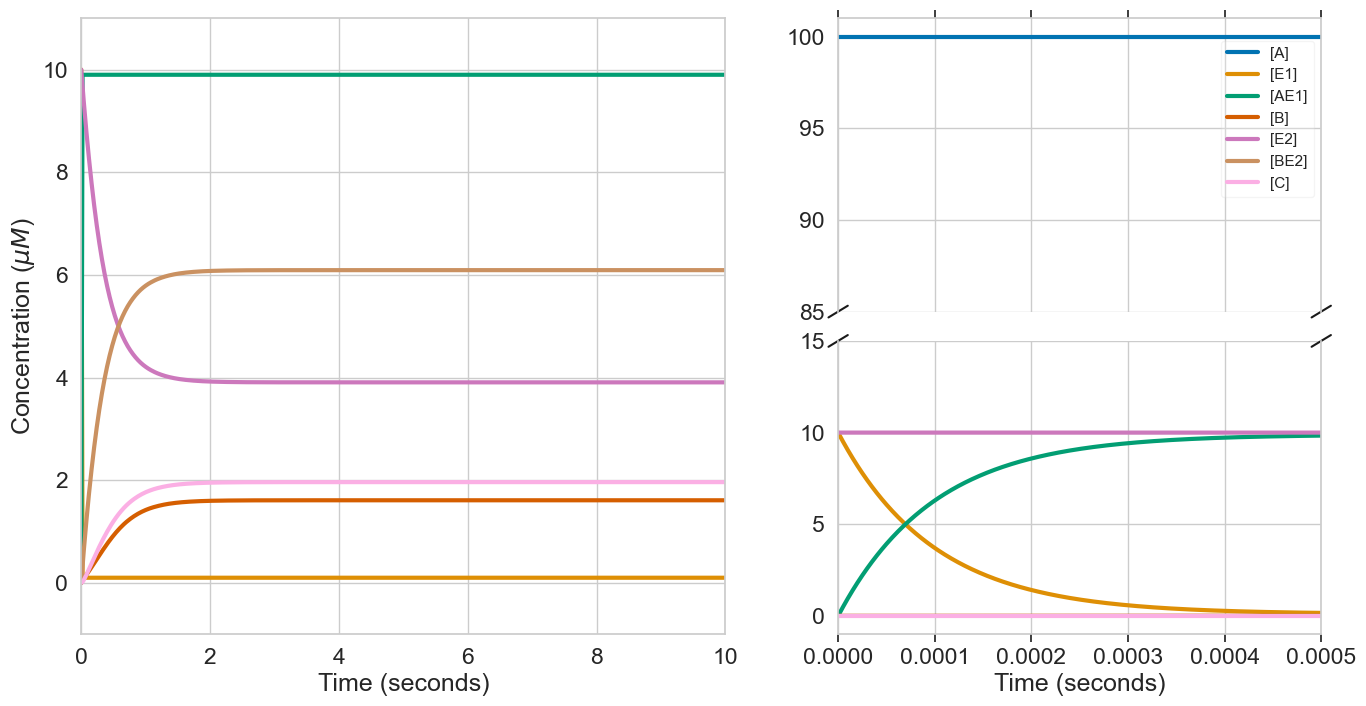

Numerical NESS at t=10s:
[A] = 100.000
[E1] = 0.101
[AE1] = 9.899
[B]   = 1.610
[E2] = 3.907
[BE2] = 6.093
[C]   = 1.964


In [5]:
# New Parameter
k3 = 10.0

y0 = [100.0, 10.0, 0.0, 0.0, 10.0, 0.0, 0.0]

def open_reversible_kinetics(t, y):
    A, E1, AE1, B, E2, BE2, C = y
    
    dA_dt = 0.0 # Replenished A
    dE1_dt = -kb * A * E1 + (ku + k1) * AE1 - k_minus1 * B * E1
    dAE1_dt = kb * A * E1 - (ku + k1) * AE1 + k_minus1 * B * E1
    
    dB_dt = k1 * AE1 - k_minus1 * B * E1 - kb * B * E2 + ku * BE2
    dE2_dt = -kb * B * E2 + (ku + k2) * BE2 - k_minus2 * C * E2
    dBE2_dt = kb * B * E2 - (ku + k2) * BE2 + k_minus2 * C * E2
    
    # constantly remove C at rate k3
    dC_dt = k2 * BE2 - k_minus2 * C * E2 - k3 * C 
    
    return [dA_dt, dE1_dt, dAE1_dt, dB_dt, dE2_dt, dBE2_dt, dC_dt]

sol_open = solve_ivp(open_reversible_kinetics, [0, 10], y0, method='Radau', dense_output=True)

t_outer = np.linspace(0, 10, 500)      
t_inner = np.linspace(0, 5e-4, 500)    

y_outer = sol_open.sol(t_outer)
y_inner = sol_open.sol(t_inner)

fig = plt.figure(figsize=(16, 8))
labels = ['[A]', '[E1]', '[AE1]', '[B]', '[E2]', '[BE2]', '[C]']
colors = sns.color_palette("colorblind", n_colors=7)
linewidth = 3

gs = gridspec.GridSpec(2, 2, height_ratios=[1, 1], width_ratios=[1, 0.75])
gs.update(hspace=0.1)

ax_outer = fig.add_subplot(gs[:, 0])            
ax_inner_top = fig.add_subplot(gs[0, 1])        
ax_inner_bot = fig.add_subplot(gs[1, 1], sharex=ax_inner_top) 

# Left Plot: Outer System
for i in range(7):
    ax_outer.plot(t_outer, y_outer[i], label=labels[i], color=colors[i], lw=linewidth)

ax_outer.set_xlabel('Time (seconds)')
ax_outer.set_ylabel('Concentration ($\mu M$)')
ax_outer.set_xlim(0, 10)
ax_outer.set_ylim(-1, 11) 

# Right Plot: Inner System
for i in range(7):
    ax_inner_top.plot(t_inner, y_inner[i], label=labels[i], color=colors[i], lw=linewidth)
    ax_inner_bot.plot(t_inner, y_inner[i], label=labels[i], color=colors[i], lw=linewidth)

ax_inner_top.set_ylim(85, 101)
ax_inner_bot.set_ylim(-1, 15)
ax_inner_bot.set_xlim(0, 5e-4)
ax_inner_bot.set_xlabel('Time (seconds)')

ax_inner_top.spines['bottom'].set_visible(False)
ax_inner_bot.spines['top'].set_visible(False)
ax_inner_top.xaxis.tick_top()
ax_inner_top.tick_params(labeltop=False)  
ax_inner_bot.xaxis.tick_bottom()

d = .02
kwargs = dict(transform=ax_inner_top.transAxes, color='k', clip_on=False, lw=1.5)
ax_inner_top.plot((-d, +d), (-d, +d), **kwargs) 
ax_inner_top.plot((1 - d, 1 + d), (-d, +d), **kwargs) 
kwargs.update(transform=ax_inner_bot.transAxes)  
ax_inner_bot.plot((-d, +d), (1 - d, 1 + d), **kwargs) 
ax_inner_bot.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)

ax_inner_top.legend(loc='upper right', fontsize=11, framealpha=0.2, bbox_to_anchor=(1.0, 0.95))

plt.show()

print(f"Numerical NESS at t=10s:")
print(f"[A] = {y_outer[0][-1]:.3f}")
print(f"[E1] = {y_outer[1][-1]:.3f}")
print(f"[AE1] = {y_outer[2][-1]:.3f}")
print(f"[B]   = {y_outer[3][-1]:.3f}")
print(f"[E2] = {y_outer[4][-1]:.3f}")
print(f"[BE2] = {y_outer[5][-1]:.3f}")
print(f"[C]   = {y_outer[6][-1]:.3f}")

#### 3 Solar Cell Detailed Balance
##### 3.1 Dark Detailed Balance

Total Solar Power: 1367.97 W/m^2
Optimal Bandgap: 1.268 eV
Optimal Voltage: 0.927 V
Max Efficiency:  30.51 %


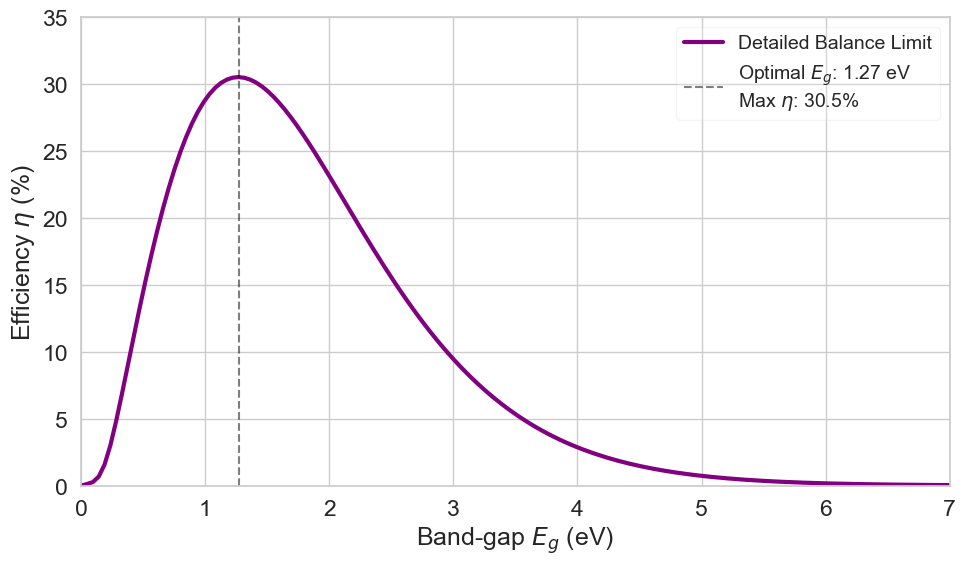

In [6]:
# Define Universal Constants
h = const.h          # Planck's constant (J*s)
c = const.c          # Speed of light (m/s)
k = const.k          # Boltzmann constant (J/K)
q = const.e          # Elementary charge (C)

Ts = 5778.0          # Temperature of the Sun (K)
Tc = 300.0           # Temperature of the Solar Cell (K)
Rs = 6.96e8          # Radius of the Sun (m)
D = 1.496e11         # Distance from Earth to Sun (m)

# Geometric factor of the sun from earth
f_geom = (Rs / D)**2 

# Thermal energies 
kT_c_J = k * Tc               
kT_s_eV = (k * Ts) / q  
kT_c_eV = (k * Tc) / q        

# Define the Solar Photon Flux
constant = (2 * np.pi * q**3) / (h**3 * c**2)

def theta_sun(E_eV):
    if E_eV / kT_s_eV > 500:
        return 0.0
    flux = constant * (E_eV**2) / (np.exp(E_eV / kT_s_eV) - 1)
    return f_geom * flux

# Calculate Total Solar Power In (Denominator for Efficiency)
def integrand_Pin(E_eV):
    return (E_eV * q) * theta_sun(E_eV)

P_in, _ = quad(integrand_Pin, 1e-4, 10.0, limit=500)
print(f"Total Solar Power: {P_in:.2f} W/m^2")

# Define the Efficiency
def calc_efficiency(Eg_eV):
    # Short Circuit Current (J_sc)
    flux_sun, _ = quad(theta_sun, Eg_eV, 10.0, limit=500)
    J_sc = q * flux_sun
    
    # J_0
    u_g = Eg_eV / kT_c_eV
    C0 = (2 * np.pi * q) / (h**3 * c**2)
    J_0 = C0 * (kT_c_J**3) * np.exp(-u_g) * (u_g**2 + 2*u_g + 2)
    
    # Define P(V)
    def p(V):
        J_rad = J_0 * (np.exp(V / kT_c_eV) - 1)
        J = J_sc - J_rad
        return -(V * J) # Negative because scipy minimizes
        
    # Optimize Voltage to find the Maximum Numerator P(V_0)
    res = minimize_scalar(p, bounds=(0, Eg_eV), method='bounded')
    P_max = -res.fun 
    
    return P_max / P_in, res.x

# Sweep across Bandgaps
Eg_vals = np.linspace(0, 7.0, 150)
results = [calc_efficiency(Eg) for Eg in Eg_vals]

efficiencies = [res[0] * 100 for res in results]
voltages = [res[1] for res in results]

# Find the peak for annotation
max_eff = max(efficiencies)
opt_idx = np.argmax(efficiencies)
opt_Eg = Eg_vals[opt_idx]
opt_V = voltages[opt_idx]

print(f"Optimal Bandgap: {opt_Eg:.3f} eV")
print(f"Optimal Voltage: {opt_V:.3f} V")
print(f"Max Efficiency:  {max_eff:.2f} %")

fig = plt.figure(figsize=(10, 6))
plt.plot(Eg_vals, efficiencies, color='purple', lw=3, label='Detailed Balance Limit')
plt.axvline(opt_Eg, color='black', linestyle='--', alpha=0.5, 
            label=f'Optimal $E_g$: {opt_Eg:.2f} eV\nMax $\eta$: {max_eff:.1f}%')
plt.xlabel('Band-gap $E_g$ (eV)')
plt.ylabel('Efficiency $\eta$ (%)')
plt.xlim(0, 7.0)
plt.ylim(0, 35)
plt.legend(framealpha=0.2, fontsize=14)
plt.tight_layout()
plt.show()